In [ ]:
from sklearn.datasets      import make_multilabel_classification
from sklearn.metrics       import classification_report
from sklearn.metrics       import label_ranking_loss
from sklearn.preprocessing import OneHotEncoder

from sklearn.manifold      import TSNE
import matplotlib.pyplot   as plt

In [21]:
X, y = make_multilabel_classification(n_features      = 5,
                                      length          = 10,
                                      n_samples       = 100,
                                      n_classes       = 4,
                                      n_labels        = 2,
                                      allow_unlabeled = False,
                                      random_state    = 42)
print(X.shape)
print(y.shape)
y[0]

(100, 5)
(100, 4)


array([1, 0, 1, 0])

In [23]:
X_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3, random_state=42).fit_transform(X)

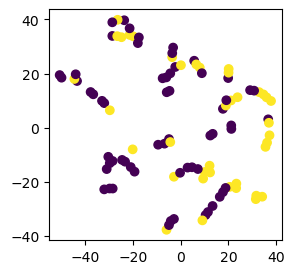

In [24]:
plt.figure(figsize=(3,3))
plt.scatter(X_embedded[:,0],X_embedded[:,1],c = y[:,0])
plt.show()

In [25]:
label_ranking_loss(y,y)

0.0

In [ ]:
import torch
torch.manual_seed(seed = 42)

import torch.nn as nn
from torch.utils.data        import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm
device = torch.device("cpu") #torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)


Device cpu


In [49]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size = 0.2,random_state = 42) 

X_train = torch.from_numpy(X_train).type(torch.float32)
Y_train = torch.from_numpy(Y_train).type(torch.float32)

X_test  = torch.from_numpy(X_test) .type(torch.float32)
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

training_dataset = TensorDataset(X_train,Y_train)
testing_dataset  = TensorDataset(X_test ,Y_test )

train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = X_train.shape[0], shuffle = False)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = X_test.shape[0] , shuffle = False)

In [ ]:
def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    model.train()
    train_losses  = []
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs).to(device)
            loss  = loss_module(preds, data_labels)
            train_losses.append(loss)

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()

    return train_losses

In [29]:
model = nn.Sequential(
    nn.Linear(5, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 4),
    nn.Sigmoid()
); model.to(device)

loss_module = torch.nn.BCELoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.01, betas = (0.9,0.99)) #(0.1,0.3)

In [33]:
hist = train_model(model       = model,
                   device      = device,
                   optimizer   = optimizer,
                   data_loader = train_loader,
                   loss_module = loss_module,
                   num_epochs  = 150)

100%|██████████| 150/150 [00:00<00:00, 536.19it/s]


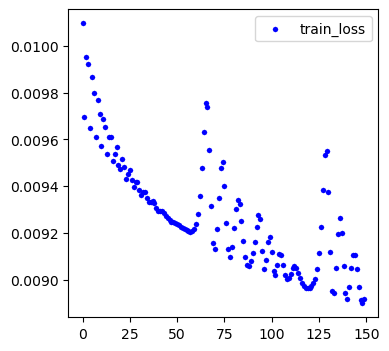

In [34]:
hist = [float(h.cpu().detach()) for h in hist]
plt.figure(figsize=(4,4))
plt.scatter(y = hist,
            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14, label = 'train_loss')
plt.legend()

In [ ]:
def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    model.train()
    train_losses  = []
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs).to(device)
            #preds = preds.squeeze(dim=1)
            loss  = loss_module(preds, data_labels)
            train_losses.append(loss)

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()

    return train_losses

In [82]:
@torch.no_grad()
def eval_model(model, device, data_loader, target_names = False):
    model.eval()
    all_pred   = torch.empty((0,), dtype = torch.float32).to(device)
    all_labels = torch.empty((0,), dtype = torch.float32).to(device)

    for data_inputs, data_labels in data_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)
        preds = model(data_inputs)
        #preds = preds.squeeze(dim=1)
        pred_labels = (preds >= 0.5).long().to(device)
        all_pred   = torch.cat((all_pred,pred_labels), dim = 0 )
        all_labels = torch.cat((all_labels,data_labels))
    print(classification_report(y_pred =   all_pred.cpu().numpy(), 
                                y_true = all_labels.cpu().numpy(), 
                                target_names  = target_names, 
                                zero_division = 0))


In [83]:
eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = [f'Label {i}' for i in range(y.shape[1])])

              precision    recall  f1-score   support

     Label 0       0.67      1.00      0.80         6
     Label 1       0.85      0.79      0.81        14
     Label 2       0.69      0.69      0.69        13
     Label 3       0.56      0.45      0.50        11

   micro avg       0.70      0.70      0.70        44
   macro avg       0.69      0.73      0.70        44
weighted avg       0.70      0.70      0.70        44
 samples avg       0.67      0.72      0.65        44

